In [100]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, os, textwrap, json, shutil
import requests
import time

In [28]:
df = pd.read_csv(r"C:\Users\sneha\Downloads\hotel_bookings (2).csv", keep_default_na=False)

In [29]:
print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")
print()
print("First 5 rows:")
display(df.head())


DATASET LOADED
Rows    : 12,000
Columns : 28

First 5 rows:


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,1,Customer_1,Group,2023-12-26,Goa,Silver,9,Maple Stay,Chennai,...,5,OTA,4877.54,0.00,,48775.40,Debit Card,Cancelled,,
1,100001,1,Customer_1,Group,2023-12-26,Goa,Silver,5,Hilltop Inn,Jaipur,...,4,Corporate Portal,2206.55,1727.18,APPDEAL,15925.22,Net Banking,Completed,4.0,2024-11-17
2,100002,1,Customer_1,Group,2023-12-26,Goa,Silver,18,Tusker Haven,Chennai,...,1,Travel Agent,5332.96,0.00,,15998.88,UPI,Completed,,
3,100003,1,Customer_1,Group,2023-12-26,Goa,Silver,44,Crimson Stay,Udaipur,...,3,Direct Website,7258.32,7971.26,FEST15,35578.66,UPI,Completed,,
4,100004,1,Customer_1,Group,2023-12-26,Goa,Silver,54,Azure Manor,Pune,...,3,Corporate Portal,6511.39,0.00,,78136.68,UPI,Completed,,


In [31]:
print()
print("Column names:")
print(df.columns.tolist())



Column names:
['booking_id', 'customer_id', 'customer_name', 'customer_segment', 'customer_signup_date', 'customer_home_city', 'customer_loyalty_tier', 'property_id', 'property_name', 'property_city', 'property_star_rating', 'property_type', 'property_total_rooms', 'booking_date', 'checkin_date', 'checkout_date', 'room_type', 'num_rooms', 'nights', 'booking_channel', 'adr', 'discount_amount', 'coupon_code', 'total_amount', 'payment_method', 'booking_status', 'review_rating', 'review_date']


## 3. Understand the Dataset Structure

In [41]:


print("=" * 70)
print("DATASET PROFILE")
print("=" * 70)

print("\n Data types:")
display(df.dtypes.to_frame("dtype"))




DATASET PROFILE

 Data types:


,dtype
booking_id,int64
customer_id,int64
customer_name,object
customer_segment,object
customer_signup_date,object
customer_home_city,object
customer_loyalty_tier,object
property_id,int64
property_name,object
property_city,object


In [43]:
print("\n Missing-value count:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\n Duplicate booking IDs:")
duplicate_count = df["booking_id"].duplicated().sum()
print(f"Duplicate booking IDs: {duplicate_count:,}")

print("\n Booking status distribution:")
display(df["booking_status"].value_counts(dropna=False).to_frame("count"))

print("\n Customer segment distribution:")
display(df["customer_segment"].value_counts(dropna=False).to_frame("count"))


 Missing-value count:


,missing_count



 Duplicate booking IDs:
Duplicate booking IDs: 0

 Booking status distribution:


,count
booking_status,
Completed,9279
Cancelled,2360
No-Show,361



 Customer segment distribution:


,count
customer_segment,
Individual,7862
Corporate,2929
Group,1209


# 4. Convert Dates and Numeric Columns"

In [44]:
date_cols = [
    "customer_signup_date",
    "booking_date",
    "checkin_date",
    "checkout_date",
    "review_date"
]

numeric_cols = [
    "num_rooms",
    "nights",
    "adr",
    "discount_amount",
    "total_amount",
    "review_rating",
    "property_star_rating",
    "property_total_rooms"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("=" * 70)
print("DATA TYPES STANDARDIZED")
print("=" * 70)
print("Date columns converted:")
print(date_cols)
print()
print("Numeric columns converted:")
print(numeric_cols)
print()
print("Updated data types:")
display(df[date_cols + numeric_cols].dtypes.to_frame("dtype"))

DATA TYPES STANDARDIZED
Date columns converted:
['customer_signup_date', 'booking_date', 'checkin_date', 'checkout_date', 'review_date']

Numeric columns converted:
['num_rooms', 'nights', 'adr', 'discount_amount', 'total_amount', 'review_rating', 'property_star_rating', 'property_total_rooms']

Updated data types:


,dtype
customer_signup_date,datetime64[ns]
booking_date,datetime64[ns]
checkin_date,datetime64[ns]
checkout_date,datetime64[ns]
review_date,datetime64[ns]
num_rooms,int64
nights,int64
adr,float64
discount_amount,float64
total_amount,float64


# 5. Data-Quality Check 1 — Invalid Stay Dates

In [46]:
invalid_stay = df["checkout_date"] <= df["checkin_date"]

print("=" * 70)
print("DQ1 — INVALID STAYS")
print("=" * 70)
print("Business rule: checkout_date must be after checkin_date.")
print(f"Invalid stay records: {invalid_stay.sum():,}")

if invalid_stay.sum() > 0:
    print("\nSample invalid records:")
    display(
        df.loc[
            invalid_stay,
            ["booking_id", "checkin_date", "checkout_date", "booking_status"]
        ].head(10)
    )

DQ1 — INVALID STAYS
Business rule: checkout_date must be after checkin_date.
Invalid stay records: 120

Sample invalid records:


,booking_id,checkin_date,checkout_date,booking_status
12,100012,2024-03-01,2024-02-29,Cancelled
90,100090,2024-02-27,2024-02-26,Completed
124,100124,2024-06-02,2024-06-02,Completed
252,100252,2024-04-07,2024-04-07,Completed
328,100328,2024-02-04,2024-02-03,Completed
417,100417,2024-01-04,2024-01-04,Cancelled
487,100487,2024-10-25,2024-10-24,Completed
511,100511,2024-05-03,2024-05-02,Completed
666,100666,2024-02-04,2024-02-04,Completed
841,100841,2024-02-27,2024-02-26,Completed


# 6. Data-Quality Check 2 — Booking Before Customer Signup

In [48]:
booking_before_signup = df["booking_date"] < df["customer_signup_date"]

print("=" * 70)
print("DQ2 — BOOKING BEFORE CUSTOMER SIGNUP")
print("=" * 70)
print("Business rule: booking_date should not be earlier than customer_signup_date.")
print(f"Invalid records: {booking_before_signup.sum():,}")

if booking_before_signup.sum() > 0:
    display(
        df.loc[
            booking_before_signup,
            [
                "booking_id",
                "customer_id",
                "customer_signup_date",
                "booking_date"
            ]
        ].head(10)
    )

DQ2 — BOOKING BEFORE CUSTOMER SIGNUP
Business rule: booking_date should not be earlier than customer_signup_date.
Invalid records: 364


,booking_id,customer_id,customer_signup_date,booking_date
122,100122,65,2024-01-23,2024-01-16
171,100171,86,2024-10-13,2024-06-21
172,100172,86,2024-10-13,2024-09-24
438,100438,231,2024-05-04,2024-04-12
439,100439,231,2024-05-04,2024-04-27
440,100440,231,2024-05-04,2024-04-14
443,100443,231,2024-05-04,2024-03-30
447,100447,231,2024-05-04,2024-01-07
483,100483,242,2024-02-27,2024-02-12
656,100656,328,2023-12-30,2023-11-25


# 7. Data-Quality Check 3 — Zero Rooms

In [49]:
zero_rooms = df["num_rooms"] == 0

print("=" * 70)
print("DQ3 — ZERO ROOM BOOKINGS")
print("=" * 70)
print("Business rule: a booking must contain at least one room.")
print(f"Zero-room records: {zero_rooms.sum():,}")

DQ3 — ZERO ROOM BOOKINGS
Business rule: a booking must contain at least one room.
Zero-room records: 60


# 8. Data-Quality Check 4 — Cancelled Booking With Review


In [51]:
cancelled_with_review = (
    df["booking_status"].eq("Cancelled")
    & df["review_rating"].notna()
)

print("=" * 70)
print("DQ4 — CANCELLED BOOKINGS WITH REVIEWS")
print("=" * 70)
print("Business rule: cancelled bookings should not have completed-stay reviews.")
print(f"Cancelled bookings with review: {cancelled_with_review.sum():,}")

if cancelled_with_review.sum() > 0:
    display(
        df.loc[
            cancelled_with_review,
            ["booking_id", "booking_status", "review_rating", "review_date"]
        ].head(10)
    )


DQ4 — CANCELLED BOOKINGS WITH REVIEWS
Business rule: cancelled bookings should not have completed-stay reviews.
Cancelled bookings with review: 50


,booking_id,booking_status,review_rating,review_date
134,100134,Cancelled,4.0,2024-02-19
486,100486,Cancelled,5.0,2024-05-30
618,100618,Cancelled,4.0,2024-04-30
660,100660,Cancelled,7.0,2024-02-11
891,100891,Cancelled,5.0,2024-11-05
925,100925,Cancelled,4.0,2024-02-07
1412,101412,Cancelled,5.0,2024-10-28
1435,101435,Cancelled,7.0,2025-01-15
1525,101525,Cancelled,3.0,2024-06-04
2064,102064,Cancelled,2.0,2024-07-15


# 9. Data-Quality Check 5 — Review Before Checkout

In [52]:
review_before_checkout = (
    df["review_date"].notna()
    & (df["review_date"] < df["checkout_date"])
)

print("=" * 70)
print("DQ5 — REVIEW BEFORE CHECKOUT")
print("=" * 70)
print("Business rule: review_date should not precede checkout_date.")
print(f"Review-before-checkout records: {review_before_checkout.sum():,}")

if review_before_checkout.sum() > 0:
    display(
        df.loc[
            review_before_checkout,
            [
                "booking_id",
                "checkin_date",
                "checkout_date",
                "review_date",
                "booking_status"
            ]
        ]
    )

DQ5 — REVIEW BEFORE CHECKOUT
Business rule: review_date should not precede checkout_date.
Review-before-checkout records: 1


,booking_id,checkin_date,checkout_date,review_date,booking_status
4945,104945,2024-04-18,2024-04-23,2024-04-21,Cancelled


# 10. Data-Quality Check 6 — Revenue Formula Consistency

In [54]:
formula_expected = (
    df["adr"]
    * df["nights"]
    * df["num_rooms"]
    - df["discount_amount"]
)

formula_mismatch = ~np.isclose(
    df["total_amount"],
    formula_expected,
    atol=0.01
)
print("=" * 70)
print("DQ6 — TOTAL AMOUNT FORMULA CHECK")
print("=" * 70)
print("Expected formula:")
print("total_amount = adr × nights × num_rooms − discount_amount")
print(f"Formula mismatch records: {formula_mismatch.sum():,}")

if formula_mismatch.sum() > 0:
    mismatch_view = df.loc[
        formula_mismatch,
        [
            "booking_id",
            "adr",
            "nights",
            "num_rooms",
            "discount_amount",
            "total_amount"
        ]
    ].copy()

    mismatch_view["formula_expected"] = formula_expected.loc[formula_mismatch]

    print("\nSample mismatches:")
    display(mismatch_view.head(10))

DQ6 — TOTAL AMOUNT FORMULA CHECK
Expected formula:
total_amount = adr × nights × num_rooms − discount_amount
Formula mismatch records: 35

Sample mismatches:


,booking_id,adr,nights,num_rooms,discount_amount,total_amount,formula_expected
16,100016,3349.28,4,1,0.00,12057.41,13397.12
545,100545,13704.54,2,1,4059.38,19290.32,23349.70
579,100579,6687.12,1,1,1338.00,6687.12,5349.12
686,100686,10825.58,2,1,4431.74,12787.68,17219.42
1221,101221,5295.95,2,1,0.00,9532.71,10591.90
1428,101428,3819.41,2,3,0.00,15277.64,22916.46
1601,101601,2557.64,3,1,0.00,6905.63,7672.92
1927,101927,5986.15,3,1,0.00,16162.60,17958.45
1929,101929,7410.40,4,1,0.00,26677.44,29641.60
2518,102518,4980.07,7,1,0.00,31374.44,34860.49


# 11. Data-Quality Check 7 — Duplicate Booking IDs

In [55]:
duplicate_booking_id = df["booking_id"].duplicated(keep=False)

print("=" * 70)
print("DQ7 — DUPLICATE BOOKING IDS")
print("=" * 70)
print(f"Rows belonging to duplicated booking IDs: {duplicate_booking_id.sum():,}")
print(f"Duplicate ID count using duplicated().sum(): {df['booking_id'].duplicated().sum():,}")

if duplicate_booking_id.sum() > 0:
    display(
        df.loc[
            duplicate_booking_id,
            ["booking_id", "customer_id", "property_id", "booking_date"]
        ].sort_values("booking_id").head(20)
    )

DQ7 — DUPLICATE BOOKING IDS
Rows belonging to duplicated booking IDs: 0
Duplicate ID count using duplicated().sum(): 0


# 12. Data-Quality Check 8 — Rating Scale

In [57]:
print("=" * 70)
print("DQ8 — REVIEW RATING SCALE")
print("=" * 70)

rating_by_segment = (
    df.groupby("customer_segment")["review_rating"]
      .agg(["min", "max", "mean", "count"])
)

display(rating_by_segment)

print("\nInterpretation:")
print("- Corporate ratings use a 1–10 scale.")
print("- Individual and Group ratings use a 1–5 scale.")
print("- Raw cross-segment averages are therefore not directly comparable.")


DQ8 — REVIEW RATING SCALE


,min,max,mean,count
customer_segment,,,,
Corporate,3.0,10.0,7.265146,1271
Group,1.0,5.0,3.828678,537
Individual,1.0,5.0,3.768972,3268



Interpretation:
- Corporate ratings use a 1–10 scale.
- Individual and Group ratings use a 1–5 scale.
- Raw cross-segment averages are therefore not directly comparable.


# 13. Data-Quality Check 9 — Literal 'None' Loyalty Tier

In [59]:
print("=" * 70)
print("DQ9 — LOYALTY TIER REPRESENTATION")
print("=" * 70)

loyalty_values = df["customer_loyalty_tier"].value_counts(dropna=False)
display(loyalty_values.to_frame("count"))

print("\nImportant handling decision:")
print("The literal string 'None' is treated as a valid loyalty-tier value,")
print("not automatically converted into a missing value.")

DQ9 — LOYALTY TIER REPRESENTATION


,count
customer_loyalty_tier,
None,5594
Silver,3283
Gold,2056
Platinum,1067



Important handling decision:
The literal string 'None' is treated as a valid loyalty-tier value,
not automatically converted into a missing value.


# 14. Undocumented DQ Issue — Room Capacity

In [60]:
dq_capacity_issue = df["num_rooms"] > df["property_total_rooms"]

print("=" * 70)
print("UNDOCUMENTED DQ CHECK — ROOM CAPACITY")
print("=" * 70)
print("Business rule tested: num_rooms should not exceed property_total_rooms.")
print(f"Potential capacity violations: {dq_capacity_issue.sum():,}")

if dq_capacity_issue.sum() > 0:
    display(
        df.loc[
            dq_capacity_issue,
            [
                "booking_id",
                "property_id",
                "property_total_rooms",
                "num_rooms"
            ]
        ].head(10)
    )

UNDOCUMENTED DQ CHECK — ROOM CAPACITY
Business rule tested: num_rooms should not exceed property_total_rooms.
Potential capacity violations: 0


# 15. Create the Analytical Population

In [61]:
# The documented analytical exclusion rules are:
# 1. invalid stay
# 2. booking before customer signup
# 3. zero rooms

analysis_mask = ~(
    invalid_stay
    | booking_before_signup
    | zero_rooms
)

clean = df.loc[analysis_mask].copy()

# Standardize coupon representation.
clean["coupon_code"] = clean["coupon_code"].replace({"": "NONE"})

# Derived analytical fields.
clean["lead_time"] = (
    clean["checkin_date"] - clean["booking_date"]
).dt.days

clean["checkin_month"] = (
    clean["checkin_date"].dt.to_period("M").astype(str)
)


clean["is_cancelled"] = (
    clean["booking_status"].eq("Cancelled").astype(int)
)

clean["is_completed"] = (
    clean["booking_status"].eq("Completed").astype(int)
)

# Preserve source revenue.
clean["total_amount_raw"] = clean["total_amount"]

# Create a corrected amount separately for sensitivity analysis.
clean["total_amount_corrected"] = (
    clean["adr"]
    * clean["nights"]
    * clean["num_rooms"]
    - clean["discount_amount"]
)
# Realized revenue = Completed bookings only.
clean["realized_revenue"] = np.where(
    clean["booking_status"].eq("Completed"),
    clean["total_amount_raw"],
    0.0
)

# Normalize Corporate ratings from 1–10 to an equivalent 1–5 scale.
clean["normalized_rating"] = np.where(
    clean["customer_segment"].eq("Corporate"),
    clean["review_rating"] / 2,
    clean["review_rating"]
)
print("=" * 70)
print("ANALYTICAL POPULATION CREATED")
print("=" * 70)
print(f"Original rows     : {len(df):,}")
print(f"Excluded rows     : {len(df) - len(clean):,}")
print(f"Analytical rows   : {len(clean):,}")
print()
print("Exclusion counts:")
print(f"- Invalid stays                 : {invalid_stay.sum():,}")
print(f"- Booking before signup         : {booking_before_signup.sum():,}")
print(f"- Zero-room bookings             : {zero_rooms.sum():,}")

ANALYTICAL POPULATION CREATED
Original rows     : 12,000
Excluded rows     : 540
Analytical rows   : 11,460

Exclusion counts:
- Invalid stays                 : 120
- Booking before signup         : 364
- Zero-room bookings             : 60


# 16. Save the Cleaned Dataset

In [65]:
from pathlib import Path

# Output folder create karo
OUTPUT_DIR = Path("/mnt/data/hotel_booking_BA_assessment_project/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Cleaned dataset save karo
output_file = OUTPUT_DIR / "cleaned_hotel_bookings.csv"

clean.to_csv(output_file, index=False)

print("=" * 70)
print("CLEAN DATASET SAVED")
print("=" * 70)
print(f"File location : {output_file}")
print(f"Rows saved    : {len(clean):,}")
print(f"Columns saved : {len(clean.columns)}")
print("=" * 70)

CLEAN DATASET SAVED
File location : \mnt\data\hotel_booking_BA_assessment_project\outputs\cleaned_hotel_bookings.csv
Rows saved    : 11,460
Columns saved : 36


# 17. DQ2 — Review Statistics After Invalid-Review Exclusions

In [66]:
review_valid = clean[
    clean["review_rating"].notna()
    & clean["booking_status"].ne("Cancelled")
    & ~(
        clean["review_date"].notna()
        & (clean["review_date"] < clean["checkout_date"])
    )
].copy()

dq2 = (
    review_valid
    .groupby("customer_segment")["review_rating"]
    .agg(
        minimum="min",
        maximum="max",
        mean="mean",
        review_count="count"
    )
)

print("=" * 70)
print("DQ2 — VALID REVIEW STATISTICS")
print("=" * 70)
display(dq2.round(3))

print("\nAnswer:")
print("Corporate ratings remain on their original 1–10 scale here.")
print("For cross-segment comparisons, use normalized_rating.")

DQ2 — VALID REVIEW STATISTICS


,minimum,maximum,mean,review_count
customer_segment,,,,
Corporate,3.0,10.0,7.263,1206
Group,1.0,5.0,3.838,501
Individual,1.0,5.0,3.766,3086


\nAnswer:
Corporate ratings remain on their original 1–10 scale here.
For cross-segment comparisons, use normalized_rating.


# 18. DQ3 — Luxury Realized Revenue

In [67]:
luxury_revenue = clean.loc[
    clean["property_type"].eq("Luxury")
    & clean["booking_status"].eq("Completed"),
    "total_amount_raw"
].sum()

luxury_corrected_revenue = clean.loc[
    clean["property_type"].eq("Luxury")
    & clean["booking_status"].eq("Completed"),
    "total_amount_corrected"
].sum()
print("=" * 70)
print("DQ3 — LUXURY REALIZED REVENUE")
print("=" * 70)
print(f"Stored total_amount revenue     : Rs {luxury_revenue:,.2f}")
print(f"Corrected formula revenue       : Rs {luxury_corrected_revenue:,.2f}")
print()
print("Final assessment answer:")
print(f"Luxury realized revenue = Rs {luxury_revenue:,.2f}")
print()
print("Why use stored total_amount?")
print("The formula mismatch is treated as a separate undocumented DQ issue.")
print("The source value is preserved instead of silently overwritten.")

DQ3 — LUXURY REALIZED REVENUE
Stored total_amount revenue     : Rs 56,060,653.54
Corrected formula revenue       : Rs 56,073,526.72

Final assessment answer:
Luxury realized revenue = Rs 56,060,653.54

Why use stored total_amount?
The formula mismatch is treated as a separate undocumented DQ issue.
The source value is preserved instead of silently overwritten.


# 19. Cancellation Crisis — Platform Baseline

In [68]:
platform_bookings = len(clean)
platform_cancellations = int(clean["is_cancelled"].sum())
platform_rate = platform_cancellations / platform_bookings

print("=" * 70)
print("CANCELLATION BASELINE")
print("=" * 70)
print(f"Analytical bookings : {platform_bookings:,}")
print(f"Cancellations      : {platform_cancellations:,}")
print(f"Cancellation rate  : {platform_rate:.2%}")
print()
print("Business interpretation:")
print("This is the baseline against which all city/month and intervention")
print("scenarios will be evaluated.")

CANCELLATION BASELINE
Analytical bookings : 11,460
Cancellations      : 2,267
Cancellation rate  : 19.78%

Business interpretation:
This is the baseline against which all city/month and intervention
scenarios will be evaluated.


# 20. CS1 — Cancellation Landscape by City and Month

In [69]:
landscape = (
    clean
    .groupby(["property_city", "checkin_month"])
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum")
    )
)

landscape["cancellation_rate"] = (
    landscape["cancellations"] / landscape["bookings"]
)

landscape_reset = landscape.reset_index()

display(
    landscape_reset.sort_values(
        "cancellation_rate",
        ascending=False
    ).head(15)
)
worst_city, worst_month = landscape["cancellation_rate"].idxmax()

worst_slice = clean[
    (clean["property_city"] == worst_city)
    & (clean["checkin_month"] == worst_month)
].copy()

print("=" * 70)
print("CS1 — WORST CITY-MONTH SLICE")
print("=" * 70)
print(f"Worst city         : {worst_city}")
print(f"Worst month        : {worst_month}")
print(f"Bookings           : {len(worst_slice):,}")
print(f"Cancellations      : {int(worst_slice['is_cancelled'].sum()):,}")
print(f"Cancellation rate  : {worst_slice['is_cancelled'].mean():.2%}")

,property_city,checkin_month,bookings,cancellations,cancellation_rate
42,Goa,2024-07,38,20,0.526316
43,Goa,2024-08,52,21,0.403846
41,Goa,2024-06,35,11,0.314286
70,Kochi,2024-11,159,46,0.289308
10,Bangalore,2024-11,57,16,0.280702
85,Mumbai,2024-02,167,45,0.269461
118,Udaipur,2024-11,92,24,0.260870
34,Delhi,2024-11,104,27,0.259615
40,Goa,2024-05,31,8,0.258065
78,Manali,2024-07,31,8,0.258065


CS1 — WORST CITY-MONTH SLICE
Worst city         : Goa
Worst month        : 2024-07
Bookings           : 38
Cancellations      : 20
Cancellation rate  : 52.63%


# 21. CS1 Visualization — Cancellation Rate Heatmap

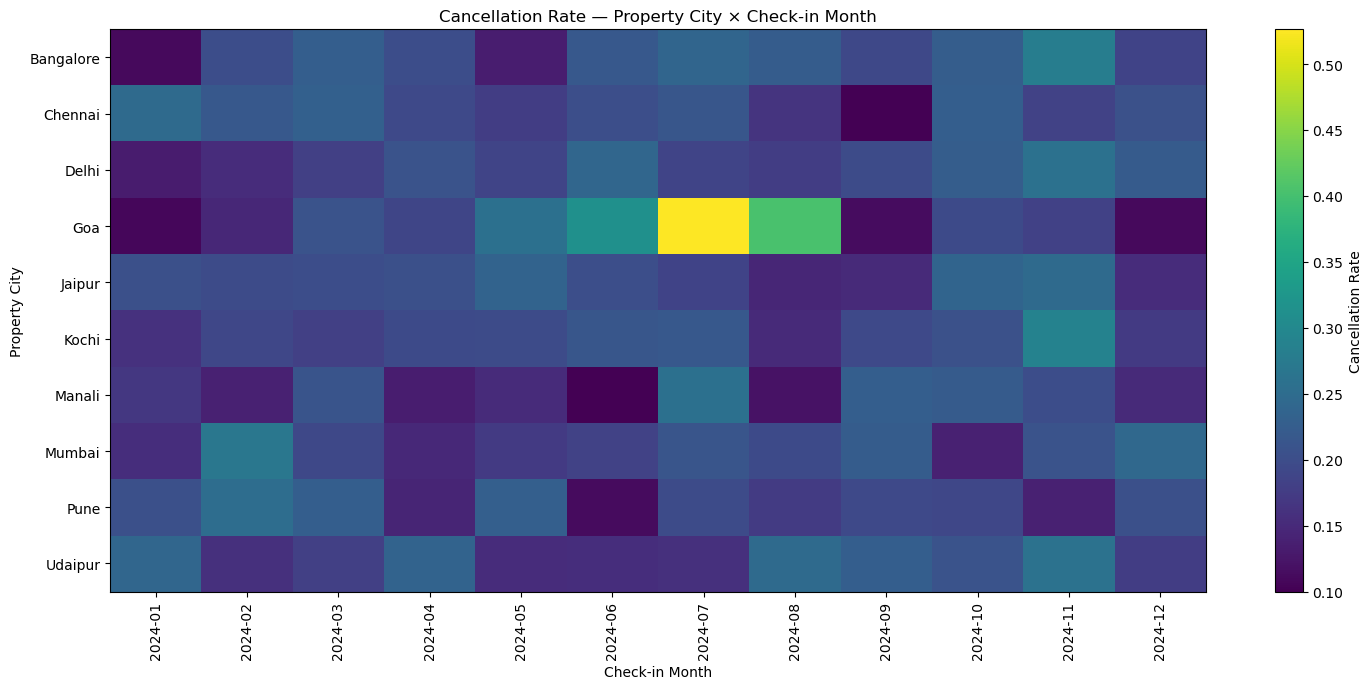

Chart saved to: \mnt\data\hotel_booking_BA_assessment_project\outputs\CS1_cancellation_landscape.png


In [71]:
pivot = landscape["cancellation_rate"].unstack("checkin_month")

fig, ax = plt.subplots(figsize=(15, 7))
image = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_title("Cancellation Rate — Property City × Check-in Month")
ax.set_xlabel("Check-in Month")
ax.set_ylabel("Property City")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Cancellation Rate")

plt.tight_layout()
plt.show()

fig.savefig(
    OUTPUT_DIR / "CS1_cancellation_landscape.png",
    dpi=200,
    bbox_inches="tight"
)
print("Chart saved to:", OUTPUT_DIR / "CS1_cancellation_landscape.png")


# 22. CS2 — Rate vs. Volume

In [74]:
top_rate = (
    landscape
    .sort_values(
        ["cancellation_rate", "bookings"],
        ascending=[False, False]
    )
    .head(3)
    .reset_index()
)

top_count = (
    landscape
    .sort_values(
        "cancellations",
        ascending=False
    )
    .head(3)
    .reset_index()
)
print("=" * 70)
print("CS2 — TOP 3 BY CANCELLATION RATE")
print("=" * 70)
display(top_rate)

print("=" * 70)
print("CS2 — TOP 3 BY CANCELLATION COUNT")
print("=" * 70)
display(top_count)

top_rate.to_csv(OUTPUT_DIR / "CS2_top3_by_rate.csv", index=False)
top_count.to_csv(OUTPUT_DIR / "CS2_top3_by_count.csv", index=False)

print("\nInterpretation:")
print("A high cancellation rate identifies severity.")
print("A high cancellation count identifies absolute business impact.")
print("Both views are needed for a platform-wide reduction target.")

CS2 — TOP 3 BY CANCELLATION RATE


,property_city,checkin_month,bookings,cancellations,cancellation_rate
0,Goa,2024-07,38,20,0.526316
1,Goa,2024-08,52,21,0.403846
2,Goa,2024-06,35,11,0.314286


CS2 — TOP 3 BY CANCELLATION COUNT


,property_city,checkin_month,bookings,cancellations,cancellation_rate
0,Kochi,2024-11,159,46,0.289308
1,Mumbai,2024-02,167,45,0.269461
2,Kochi,2024-07,170,37,0.217647



Interpretation:
A high cancellation rate identifies severity.
A high cancellation count identifies absolute business impact.
Both views are needed for a platform-wide reduction target.


# 23. CS3 — Hypothesis A: Lead-Time Mix

In [75]:
rest = clean.drop(worst_slice.index)

clean["lead_bucket"] = pd.cut(
    clean["lead_time"],
    bins=[-1, 7, 14, 30, 60, 90, 10**9],
    labels=["0-7", "8-14", "15-30", "31-60", "61-90", "91+"]
)

worst_slice["lead_bucket"] = pd.cut(
    worst_slice["lead_time"],
    bins=[-1, 7, 14, 30, 60, 90, 10**9],
    labels=["0-7", "8-14", "15-30", "31-60", "61-90", "91+"]
)

rest["lead_bucket"] = pd.cut(
    rest["lead_time"],
    bins=[-1, 7, 14, 30, 60, 90, 10**9],
    labels=["0-7", "8-14", "15-30", "31-60", "61-90", "91+"]
)
lead_worst = (
    worst_slice
    .groupby("lead_bucket", observed=True)
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum")
    )
)
lead_worst["rate"] = lead_worst["cancellations"] / lead_worst["bookings"]

lead_rest = (
    rest
    .groupby("lead_bucket", observed=True)
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum")
    )
)
lead_rest["rate"] = lead_rest["cancellations"] / lead_rest["bookings"]

expected_lead_cancel = sum(
    row["bookings"] * lead_rest.loc[bucket, "rate"]
    for bucket, row in lead_worst.iterrows()
    if bucket in lead_rest.index
)

expected_lead_rate = expected_lead_cancel / len(worst_slice)

print("=" * 70)
print("CS3 — LEAD-TIME STANDARDIZATION")
print("=" * 70)
print(f"Actual worst-slice rate       : {worst_slice['is_cancelled'].mean():.2%}")
print(f"Expected standardized rate    : {expected_lead_rate:.2%}")
print()
print("Conclusion:")
if expected_lead_rate < worst_slice["is_cancelled"].mean():
    print("Lead-time mix alone does NOT explain the cancellation spike.")
else:
    print("Lead-time mix may explain a substantial part of the spike.")

CS3 — LEAD-TIME STANDARDIZATION
Actual worst-slice rate       : 52.63%
Expected standardized rate    : 18.82%

Conclusion:
Lead-time mix alone does NOT explain the cancellation spike.


# 24. CS3 — Hypothesis B: Channel Mix

In [76]:
channel_worst = (
    worst_slice
    .groupby("booking_channel")
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum")
    )
)
channel_worst["rate"] = (
    channel_worst["cancellations"] / channel_worst["bookings"]
)

channel_rest = (
    rest
    .groupby("booking_channel")
    .agg(
        bookings=("booking_id", "size"),
        cancellations=("is_cancelled", "sum")
    )
)
channel_rest["rate"] = (
    channel_rest["cancellations"] / channel_rest["bookings"]
)

expected_channel_cancel = sum(
    row["bookings"] * channel_rest.loc[channel, "rate"]
    for channel, row in channel_worst.iterrows()
    if channel in channel_rest.index
)

expected_channel_rate = expected_channel_cancel / len(worst_slice)

print("=" * 70)
print("CS3 — CHANNEL MIX STANDARDIZATION")
print("=" * 70)
print(f"Actual worst-slice rate       : {worst_slice['is_cancelled'].mean():.2%}")
print(f"Expected standardized rate    : {expected_channel_rate:.2%}")
print()
print("Conclusion:")
if expected_channel_rate < worst_slice["is_cancelled"].mean():
    print("Channel mix alone does NOT explain the cancellation spike.")
else:
    print("Channel mix may explain a substantial part of the spike.")

CS3 — CHANNEL MIX STANDARDIZATION
Actual worst-slice rate       : 52.63%
Expected standardized rate    : 18.97%

Conclusion:
Channel mix alone does NOT explain the cancellation spike.


# 25. CS3 — Hypothesis C: City-Season Interaction

In [77]:
city_other = clean[
    (clean["property_city"] == worst_city)
    & (clean["checkin_month"] != worst_month)
]

same_month_other_city = clean[
    (clean["property_city"] != worst_city)
    & (clean["checkin_month"] == worst_month)
]

comparison = pd.DataFrame({
    "comparison": [
        "Worst city-month",
        f"{worst_city} — other months",
        f"Other cities — same month"
    ],
    "bookings": [
        len(worst_slice),
        len(city_other),
        len(same_month_other_city)
    ],
       "cancellation_rate": [
        worst_slice["is_cancelled"].mean(),
        city_other["is_cancelled"].mean(),
        same_month_other_city["is_cancelled"].mean()
    ]
})

print("=" * 70)
print("CS3 — CITY-SEASON COMPARISON")
print("=" * 70)
display(comparison)

print("\nInterpretation:")
print(
    f"{worst_city} in {worst_month} has a cancellation rate of "
    f"{worst_slice['is_cancelled'].mean():.2%}."
)
print(
    f"The same city in other months is "
    f"{city_other['is_cancelled'].mean():.2%}."
)
print(
    f"Other cities in {worst_month} are at "
    f"{same_month_other_city['is_cancelled'].mean():.2%}."
)
print()
print("Conclusion: the evidence most strongly supports a localized")
print("city-season interaction, while recognizing that this is")
print("observational evidence rather than causal proof.")

CS3 — CITY-SEASON COMPARISON


,comparison,bookings,cancellation_rate
0,Worst city-month,38,0.526316
1,Goa — other months,418,0.210526
2,Other cities — same month,933,0.203644


\nInterpretation:
Goa in 2024-07 has a cancellation rate of 52.63%.
The same city in other months is 21.05%.
Other cities in 2024-07 are at 20.36%.

Conclusion: the evidence most strongly supports a localized
city-season interaction, while recognizing that this is
observational evidence rather than causal proof.


# 26. CS3 Visualization — Root-Cause Comparison

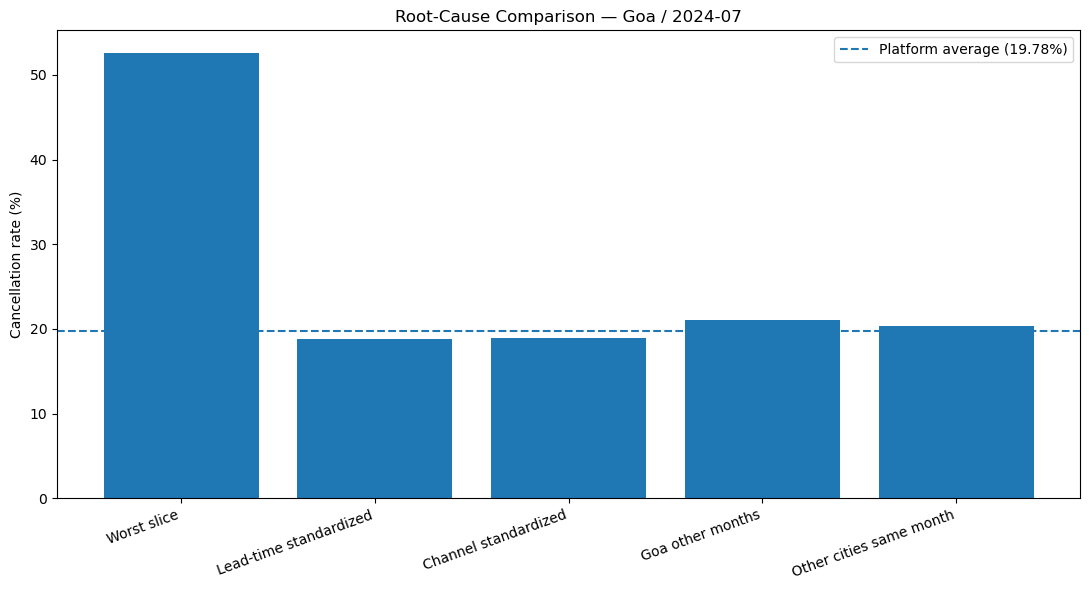

In [78]:
hypothesis_values = pd.Series({
    "Worst slice": worst_slice["is_cancelled"].mean(),
    "Lead-time standardized": expected_lead_rate,
    "Channel standardized": expected_channel_rate,
    f"{worst_city} other months": city_other["is_cancelled"].mean(),
    f"Other cities same month": same_month_other_city["is_cancelled"].mean()
})

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(
    range(len(hypothesis_values)),
    hypothesis_values.values * 100
)

ax.axhline(
    platform_rate * 100,
    linestyle="--",
    label=f"Platform average ({platform_rate:.2%})"
)
ax.set_xticks(range(len(hypothesis_values)))
ax.set_xticklabels(
    hypothesis_values.index,
    rotation=20,
    ha="right"
)
ax.set_ylabel("Cancellation rate (%)")
ax.set_title(f"Root-Cause Comparison — {worst_city} / {worst_month}")
ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(
    OUTPUT_DIR / "CS3_root_cause_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

# 27. CS4 — What-If Scenario 1: Worst Slice to Platform Average")


In [79]:
worst_current_cancel = int(worst_slice["is_cancelled"].sum())

worst_expected_at_platform = (
    len(worst_slice) * platform_rate
)

worst_prevented = (
    worst_current_cancel - worst_expected_at_platform
)

worst_pp = (
    worst_prevented / len(clean) * 100
)

print("=" * 70)
print("CS4 — WHAT-IF SCENARIO 1")
print("=" * 70)

print(f"Current worst-slice cancellations : {worst_current_cancel}")
print(f"Worst-slice bookings              : {len(worst_slice):,}")
print(f"Platform cancellation rate        : {platform_rate:.6f}")
print()
print("Arithmetic:")
print(
    f"Expected cancellations = "
    f"{len(worst_slice)} × {platform_rate:.6f}"
)
print(f"Expected cancellations = {worst_expected_at_platform:.2f}")
print()

print(
    f"Prevented cancellations = "
    f"{worst_current_cancel} - {worst_expected_at_platform:.2f}"
)
print(f"Prevented cancellations = {worst_prevented:.2f}")
print()

print(
    f"Platform reduction = "
    f"{worst_prevented:.2f} / {len(clean):,} × 100"
)
print(f"Platform reduction = {worst_pp:.2f} percentage points")

CS4 — WHAT-IF SCENARIO 1
Current worst-slice cancellations : 20
Worst-slice bookings              : 38
Platform cancellation rate        : 0.197818

Arithmetic:
Expected cancellations = 38 × 0.197818
Expected cancellations = 7.52

Prevented cancellations = 20 - 7.52
Prevented cancellations = 12.48

Platform reduction = 12.48 / 11,460 × 100
Platform reduction = 0.11 percentage points


# 28. CS4 — What-If Scenario 2: Lead Time >30 Days

In [80]:
long_lead = clean[clean["lead_time"] > 30]
short_lead = clean[clean["lead_time"] <= 30]

long_current_cancel = int(long_lead["is_cancelled"].sum())
long_current_rate = long_lead["is_cancelled"].mean()
short_rate = short_lead["is_cancelled"].mean()

long_expected_cancel = len(long_lead) * short_rate

long_prevented = (
    long_current_cancel - long_expected_cancel
)

long_pp = (
    long_prevented / len(clean) * 100
)
print("=" * 70)
print("CS4 — WHAT-IF SCENARIO 2")
print("=" * 70)

print(f"Lead time >30 days bookings : {len(long_lead):,}")
print(f"Lead time >30 cancellations  : {long_current_cancel:,}")
print(f"Lead time >30 rate           : {long_current_rate:.2%}")
print()
print(f"Lead time <=30 rate          : {short_rate:.2%}")
print()

print("Arithmetic:")
print(
    f"Expected long-lead cancellations = "
    f"{len(long_lead):,} × {short_rate:.6f}"
)
print(f"Expected cancellations = {long_expected_cancel:.2f}")
print()
print(
    f"Prevented cancellations = "
    f"{long_current_cancel} - {long_expected_cancel:.2f}"
)
print(f"Prevented cancellations = {long_prevented:.2f}")
print()

print(
    f"Platform reduction = "
    f"{long_prevented:.2f} / {len(clean):,} × 100"
)
print(f"Platform reduction = {long_pp:.2f} percentage points")

CS4 — WHAT-IF SCENARIO 2
Lead time >30 days bookings : 3,349
Lead time >30 cancellations  : 772
Lead time >30 rate           : 23.05%

Lead time <=30 rate          : 18.43%

Arithmetic:
Expected long-lead cancellations = 3,349 × 0.184318
Expected cancellations = 617.28

Prevented cancellations = 772 - 617.28
Prevented cancellations = 154.72

Platform reduction = 154.72 / 11,460 × 100
Platform reduction = 1.35 percentage points


# 29. CS4 — Combined Scenario Without Double Counting

In [81]:
long_non_worst = clean[
    (clean["lead_time"] > 30)
    & ~(
        (clean["property_city"] == worst_city)
        & (clean["checkin_month"] == worst_month)
    )
]

second_delta = (
    long_non_worst["is_cancelled"].sum()
    - len(long_non_worst) * short_rate
)
combined_prevented = worst_prevented + second_delta
combined_pp = combined_prevented / len(clean) * 100

print("=" * 70)
print("CS4 — COMBINED SCENARIO")
print("=" * 70)
print("The second intervention excludes the already-treated worst slice.")
print("This avoids double counting overlapping bookings.")
print()
print(f"Worst-slice contribution : {worst_prevented:.2f} cancellations")
print(f"Second contribution      : {second_delta:.2f} cancellations")
print(f"Combined prevented       : {combined_prevented:.2f} cancellations")
print(f"Combined platform impact : {combined_pp:.2f} percentage points")

CS4 — COMBINED SCENARIO
The second intervention excludes the already-treated worst slice.
This avoids double counting overlapping bookings.

Worst-slice contribution : 12.48 cancellations
Second contribution      : 154.46 cancellations
Combined prevented       : 166.94 cancellations
Combined platform impact : 1.46 percentage points


# 30. CS5 — Business Recommendation

In [82]:
print("=" * 70)
print("CS5 — BUSINESS RECOMMENDATION")
print("=" * 70)

print("TARGET")
print("Bookings made more than 30 days before check-in.")
print()

print("PRIORITIZATION")
print("Prioritize high-volume channels such as OTA and Corporate Portal")
print("for a controlled operational pilot.")
print()

print("PROPOSED POLICY")
print("Introduce a partial non-refundable deposit or reduced-refund tier")
print("for long-lead bookings while retaining a flexible option for")
print("shorter-lead customers.")
print()

print("EVIDENCE")
print(f">30-day cancellation rate : {long_current_rate:.2%}")
print(f"<=30-day cancellation rate: {short_rate:.2%}")
print(f"Observed counterfactual impact: {long_pp:.2f} percentage points")
print()
print("RISK")
print("A stricter policy may reduce conversion, customer satisfaction,")
print("or shift demand toward competitors with more flexible policies.")
print()

print("RECOMMENDED TEST")
print("Run a controlled pilot and track conversion, cancellation rate,")
print("revenue, refund cost, complaints, and channel mix before rollout.")

CS5 — BUSINESS RECOMMENDATION
TARGET
Bookings made more than 30 days before check-in.

PRIORITIZATION
Prioritize high-volume channels such as OTA and Corporate Portal
for a controlled operational pilot.

PROPOSED POLICY
Introduce a partial non-refundable deposit or reduced-refund tier
for long-lead bookings while retaining a flexible option for
shorter-lead customers.

EVIDENCE
>30-day cancellation rate : 23.05%
<=30-day cancellation rate: 18.43%
Observed counterfactual impact: 1.35 percentage points

RISK
A stricter policy may reduce conversion, customer satisfaction,
or shift demand toward competitors with more flexible policies.

RECOMMENDED TEST
Run a controlled pilot and track conversion, cancellation rate,
revenue, refund cost, complaints, and channel mix before rollout.


# 31. CS6 — Is the Board's 5-Point Target Achievable?

In [83]:
print("=" * 70)
print("CS6 — BOARD TARGET ASSESSMENT")
print("=" * 70)

print(f"Worst-slice scenario impact : {worst_pp:.2f} pp")
print(f"Long-lead scenario impact   : {long_pp:.2f} pp")
print(f"Combined tested impact      : {combined_pp:.2f} pp")
print("Board target                : 5.00 pp")
print()

if combined_pp >= 5:
    print("Conclusion: the tested interventions could support the target.")
else:
    print("Conclusion: the 5-point target is NOT supported by the tested")
    print("interventions in this dataset.")
    print()
    print("Additional data/levers required:")
    print("- Cancellation reason")
    print("- Refund-policy exposure")
    print("- Payment failure information")
    print("- Booking price changes")
    print("- Customer intent")
    print("- Events / holidays / weather")
    print("- Property-level cancellation policies")
    print("- Controlled A/B or phased policy testing")

CS6 — BOARD TARGET ASSESSMENT
Worst-slice scenario impact : 0.11 pp
Long-lead scenario impact   : 1.35 pp
Combined tested impact      : 1.46 pp
Board target                : 5.00 pp

Conclusion: the 5-point target is NOT supported by the tested
interventions in this dataset.

Additional data/levers required:
- Cancellation reason
- Refund-policy exposure
- Payment failure information
- Booking price changes
- Customer intent
- Events / holidays / weather
- Property-level cancellation policies
- Controlled A/B or phased policy testing


# 34. Weather API Mini-Project — Setup

In [84]:

API_URL = "https://archive-api.open-meteo.com/v1/archive"

In [85]:
CITY_COORDS = {
    "Goa": {
        "latitude": 15.2993,
        "longitude": 74.1240
    },
    "Manali": {
        "latitude": 32.2396,
        "longitude": 77.1887
    }
}
print("=" * 70)
print("WEATHER API MINI-PROJECT")
print("=" * 70)
print("API:", API_URL)
print("Cities:", list(CITY_COORDS.keys()))

WEATHER API MINI-PROJECT
API: https://archive-api.open-meteo.com/v1/archive
Cities: ['Goa', 'Manali']


# 35. Select Goa and Manali 2024 Bookings

In [86]:
weather_sample = clean[
    clean["property_city"].isin(CITY_COORDS.keys())
    & (clean["checkin_date"].dt.year == 2024)
].copy()

weather_sample["is_cancel_or_noshow"] = (
    weather_sample["booking_status"].isin(
        ["Cancelled", "No-Show"]
    ).astype(int)
)

city_dates = (
    weather_sample[
        ["property_city", "checkin_date"]
    ]
    .drop_duplicates()
    .sort_values(["property_city", "checkin_date"])
)

print("=" * 70)
print("WEATHER SAMPLE")
print("=" * 70)
print(f"Bookings selected: {len(weather_sample):,}")
print(f"Unique city/date combinations: {len(city_dates):,}")
display(city_dates.head(10))

WEATHER SAMPLE
Bookings selected: 926
Unique city/date combinations: 518


,property_city,checkin_date
8536,Goa,2024-01-02
9483,Goa,2024-01-05
10047,Goa,2024-01-06
1143,Goa,2024-01-10
3517,Goa,2024-01-11
6715,Goa,2024-01-12
271,Goa,2024-01-14
11961,Goa,2024-01-15
7999,Goa,2024-01-16
31,Goa,2024-01-18


# 36. Fetch Historical Weather With Retry Handling

In [95]:
def fetch_city_weather(city, start_date, end_date, max_retries=3):
    """Fetch city-level historical weather safely."""
    
    coord = CITY_COORDS[city]

    params = {
        "latitude": coord["latitude"],
        "longitude": coord["longitude"],
        "start_date": start_date,
        "end_date": end_date,
        "daily": "precipitation_sum,temperature_2m_max",
        "timezone": "auto"
    }

    for attempt in range(1, max_retries + 1):
        try:
            print(
                f"Requesting {city}: {start_date} to {end_date} "
                f"(attempt {attempt}/{max_retries})"
            )

            response = requests.get(
                API_URL,
                params=params,
                timeout=30
            )
            response.raise_for_status()

            payload = response.json()

            if "daily" not in payload:
                raise ValueError("API response does not contain daily data.")

            daily = payload["daily"]

            weather = pd.DataFrame({
                "checkin_date": pd.to_datetime(daily["time"]),
                "precipitation_sum": daily["precipitation_sum"],
                "temperature_2m_max": daily["temperature_2m_max"]
            })
            weather["property_city"] = city

            print(f"Success: {len(weather):,} daily weather rows returned.")
            return weather

        except Exception as exc:
            print(f"API attempt failed: {exc}")

            if attempt < max_retries:
                wait_seconds = 2 ** (attempt - 1)
                print(f"Waiting {wait_seconds} seconds before retry...")
                time.sleep(wait_seconds)

    print(f"WARNING: no weather data returned for {city}.")

    return pd.DataFrame(
        columns=[
            "property_city",
            "checkin_date",
            "precipitation_sum",
            "temperature_2m_max"]
    )
       

# 37. Download Weather in City-Level Batches

In [101]:
weather_frames = []

for city in CITY_COORDS:

    city_dates_only = city_dates[
        city_dates["property_city"] == city
    ]

    if city_dates_only.empty:
        print(f"No 2024 bookings found for {city}.")
        continue

    start_date = (
        city_dates_only["checkin_date"]
        .min()
        .strftime("%Y-%m-%d")
    )

    end_date = (
        city_dates_only["checkin_date"]
        .max()
        .strftime("%Y-%m-%d")
    )

    weather_df = fetch_city_weather(
        city,
        start_date,
        end_date
    )

    weather_frames.append(weather_df)

if weather_frames:
    weather = pd.concat(
        weather_frames,
        ignore_index=True
    )
else:
    weather = pd.DataFrame(
        columns=[
            "property_city",
            "checkin_date",
            "precipitation_sum",
            "temperature_2m_max"
        ]
    )

print("=" * 70)
print("WEATHER DATA COLLECTION COMPLETE")
print("=" * 70)
print(f"Weather rows collected: {len(weather):,}")
display(weather.head())

Requesting Goa: 2024-01-02 to 2024-12-29 (attempt 1/3)
Success: 363 daily weather rows returned.
Requesting Manali: 2024-01-01 to 2024-12-31 (attempt 1/3)
Success: 366 daily weather rows returned.
WEATHER DATA COLLECTION COMPLETE
Weather rows collected: 729


,checkin_date,precipitation_sum,temperature_2m_max,property_city
0,2024-01-02,0.0,35.4,Goa
1,2024-01-03,0.0,34.6,Goa
2,2024-01-04,13.5,32.7,Goa
3,2024-01-05,0.1,31.2,Goa
4,2024-01-06,3.8,31.7,Goa


# 38. Merge Weather With Bookings

In [102]:
if not weather.empty:

    enriched = weather_sample.merge(
        weather,
        on=["property_city", "checkin_date"],
        how="left",
        validate="many_to_one"
    )

    print("=" * 70)
    print("WEATHER MERGE COMPLETE")
    print("=" * 70)
    print(f"Enriched booking rows: {len(enriched):,}")
    print(
        f"Bookings with weather: "
        f"{enriched['precipitation_sum'].notna().sum():,}"
    )
    display(
        enriched[
            [
                "booking_id",
                "property_city",
                "checkin_date",
                "booking_status",
                "precipitation_sum",
                "temperature_2m_max"
            ]
        ].head(10)
    )

else:
    enriched = weather_sample.copy()
    enriched["precipitation_sum"] = np.nan
    enriched["temperature_2m_max"] = np.nan

    print("No weather data available. API section was skipped safely.")

WEATHER MERGE COMPLETE
Enriched booking rows: 926
Bookings with weather: 926


,booking_id,property_city,checkin_date,booking_status,precipitation_sum,temperature_2m_max
0,100008,Goa,2024-04-19,Completed,0.2,37.8
1,100023,Goa,2024-09-16,Completed,3.8,29.1
2,100031,Goa,2024-01-18,Completed,0.0,31.8
3,100032,Manali,2024-12-29,Completed,1.0,11.8
4,100034,Goa,2024-12-04,Completed,0.8,33.8
5,100036,Manali,2024-11-17,Completed,2.5,13.8
6,100045,Goa,2024-11-30,Completed,0.0,34.7
7,100046,Manali,2024-09-20,Completed,0.0,26.8
8,100063,Manali,2024-01-28,Completed,14.2,11.8
9,100077,Manali,2024-12-24,Completed,26.1,8.1


# 39. Create Heavy-Rain and Extreme-Temperature Flags

In [104]:
if not weather.empty:

    enriched = weather_sample.merge(
        weather,
        on=["property_city", "checkin_date"],
        how="left",
        validate="many_to_one"
    )

    print("=" * 70)
    print("WEATHER MERGE COMPLETE")
    print("=" * 70)
    print(f"Enriched booking rows: {len(enriched):,}")
    print(
        f"Bookings with weather: "
        f"{enriched['precipitation_sum'].notna().sum():,}"
    )

    display(
        enriched[
            [
                "booking_id",
                "property_city",
                "checkin_date",
                "booking_status",
                "precipitation_sum",
                "temperature_2m_max"
            ]
        ].head(10)
    )

else:
    enriched = weather_sample.copy()
    enriched["precipitation_sum"] = np.nan
    enriched["temperature_2m_max"] = np.nan

    print("No weather data available. API section was skipped safely.")

WEATHER MERGE COMPLETE
Enriched booking rows: 926
Bookings with weather: 926


,booking_id,property_city,checkin_date,booking_status,precipitation_sum,temperature_2m_max
0,100008,Goa,2024-04-19,Completed,0.2,37.8
1,100023,Goa,2024-09-16,Completed,3.8,29.1
2,100031,Goa,2024-01-18,Completed,0.0,31.8
3,100032,Manali,2024-12-29,Completed,1.0,11.8
4,100034,Goa,2024-12-04,Completed,0.8,33.8
5,100036,Manali,2024-11-17,Completed,2.5,13.8
6,100045,Goa,2024-11-30,Completed,0.0,34.7
7,100046,Manali,2024-09-20,Completed,0.0,26.8
8,100063,Manali,2024-01-28,Completed,14.2,11.8
9,100077,Manali,2024-12-24,Completed,26.1,8.1


# 39. Create Heavy-Rain and Extreme-Temperature Flags

In [105]:
if not enriched.empty:

    enriched["heavy_rain"] = (
        enriched["precipitation_sum"] >= 20
    )

    temp_limits = (
        enriched
        .groupby("property_city")["temperature_2m_max"]
        .quantile([0.05, 0.95])
        .unstack()
        .rename(
            columns={
                0.05: "p05",
                0.95: "p95"
            }
        )
        .reset_index()
    )

    enriched = enriched.merge(
        temp_limits,
        on="property_city",
        how="left"
    )

    enriched["extreme_temperature"] = (
        (enriched["temperature_2m_max"] < enriched["p05"])
        | (enriched["temperature_2m_max"] > enriched["p95"])
    )

    print("=" * 70)
    print("WEATHER FLAGS CREATED")
    print("=" * 70)
    print("Heavy rain rule: precipitation >= 20 mm/day")
    print("Extreme temperature rule: city-specific 5th/95th percentile")
    display(
        enriched[
            [
                "property_city",
                "checkin_date",
                "precipitation_sum",
                "temperature_2m_max",
                "heavy_rain",
                "extreme_temperature"
            ]
        ].head(10)
    )

WEATHER FLAGS CREATED
Heavy rain rule: precipitation >= 20 mm/day
Extreme temperature rule: city-specific 5th/95th percentile


,property_city,checkin_date,precipitation_sum,temperature_2m_max,heavy_rain,extreme_temperature
0,Goa,2024-04-19,0.2,37.8,False,False
1,Goa,2024-09-16,3.8,29.1,False,False
2,Goa,2024-01-18,0.0,31.8,False,False
3,Manali,2024-12-29,1.0,11.8,False,False
4,Goa,2024-12-04,0.8,33.8,False,False
5,Manali,2024-11-17,2.5,13.8,False,False
6,Goa,2024-11-30,0.0,34.7,False,False
7,Manali,2024-09-20,0.0,26.8,False,True
8,Manali,2024-01-28,14.2,11.8,False,False
9,Manali,2024-12-24,26.1,8.1,True,False


# 40. Quantify the Weather Cancellation Insight

In [106]:
def summarize_weather_flag(data, flag_column):
    flagged = data[
        data[flag_column].notna()
        & data[flag_column]
    ]

    normal = data[
        data[flag_column].notna()
        & ~data[flag_column]
    ]

    if flagged.empty or normal.empty:
        return None

    flagged_rate = flagged["is_cancel_or_noshow"].mean()
    normal_rate = normal["is_cancel_or_noshow"].mean()

    return {
        "weather_condition": flag_column,
        "condition_bookings": len(flagged),
        "condition_cancel_noshow_rate": flagged_rate,
        "normal_bookings": len(normal),
        "normal_cancel_noshow_rate": normal_rate,
        "rate_difference_pp": (
            flagged_rate - normal_rate
        ) * 100
    }

if not enriched.empty:
    weather_results = []

    for flag in [
        "heavy_rain",
        "extreme_temperature"
    ]:
        result = summarize_weather_flag(
            enriched,
            flag
        )

        if result is not None:
            weather_results.append(result)

    weather_summary = pd.DataFrame(weather_results)

    print("=" * 70)
    print("WEATHER CANCELLATION INSIGHT")
    print("=" * 70)

    if weather_summary.empty:
        print("No complete weather comparison was available.")
    else:
        display(weather_summary)

        best = weather_summary.iloc[
            weather_summary["rate_difference_pp"].abs().argmax()
        ]

        print()
        print("Quantified insight:")
        print(
            f"{best['weather_condition']} days show a "
            f"{best['rate_difference_pp']:.2f} percentage-point "
            f"difference in cancellation/no-show rate versus normal days."
        )
else:
    weather_summary = pd.DataFrame()
    print("Weather enrichment unavailable.")

WEATHER CANCELLATION INSIGHT


,weather_condition,condition_bookings,condition_cancel_noshow_rate,normal_bookings,normal_cancel_noshow_rate,rate_difference_pp
0,heavy_rain,145,0.358621,781,0.217670,14.095104
1,extreme_temperature,91,0.241758,835,0.239521,0.223728



Quantified insight:
heavy_rain days show a 14.10 percentage-point difference in cancellation/no-show rate versus normal days.


# 41. Final Business Answer — DQ Findings

In [107]:
print("=" * 80)
print("FINAL ANSWERS — SECTION 1: DATA FORENSICS")
print("=" * 80)

print(f"DQ1 — Invalid stays: {invalid_stay.sum():,} bookings")
print(
    f"DQ2 — Booking before signup: "
    f"{booking_before_signup.sum():,} bookings"
)
print(f"DQ3 — Zero rooms: {zero_rooms.sum():,} bookings")
print(
    f"DQ4 — Cancelled bookings with review: "
    f"{cancelled_with_review.sum():,}"
)
print(
    f"DQ5 — Review before checkout: "
    f"{review_before_checkout.sum():,}"
)
print(
    f"DQ6 — Revenue formula mismatches: "
    f"{formula_mismatch.sum():,}"
)
print(
    f"DQ7 — Duplicate booking IDs: "
    f"{df['booking_id'].duplicated().sum():,}"
)
print()
print(f"DQ3 Business Answer — Luxury realized revenue: Rs {luxury_revenue:,.2f}")
print()
print("Undocumented issue:")
print(
    f"{formula_mismatch.sum():,} rows do not satisfy "
    "total_amount = adr × nights × num_rooms − discount."
)
print("Handling: preserve raw revenue and create corrected revenue separately.")

FINAL ANSWERS — SECTION 1: DATA FORENSICS
DQ1 — Invalid stays: 120 bookings
DQ2 — Booking before signup: 364 bookings
DQ3 — Zero rooms: 60 bookings
DQ4 — Cancelled bookings with review: 50
DQ5 — Review before checkout: 1
DQ6 — Revenue formula mismatches: 35
DQ7 — Duplicate booking IDs: 0

DQ3 Business Answer — Luxury realized revenue: Rs 56,060,653.54

Undocumented issue:
35 rows do not satisfy total_amount = adr × nights × num_rooms − discount.
Handling: preserve raw revenue and create corrected revenue separately.


# 42. Final Business Answer — Cancellation Crisis

In [108]:
print("=" * 80)
print("FINAL ANSWERS — SECTION 2: CANCELLATION CRISIS")
print("=" * 80)

print(f"Platform cancellation rate: {platform_rate:.2%}")
print()
print(
    f"Worst slice: {worst_city} / {worst_month} "
    f"with {len(worst_slice):,} bookings and "
    f"{worst_slice['is_cancelled'].mean():.2%} cancellation rate."
)
print()
print(
    f"Lead-time standardized expected rate: "
    f"{expected_lead_rate:.2%}"
)
print(
    f"Channel standardized expected rate: "
    f"{expected_channel_rate:.2%}"
)
print()
print(
    f"Scenario 1 impact: {worst_pp:.2f} percentage points"
)
print(
    f"Scenario 2 impact: {long_pp:.2f} percentage points"
)
print(
    f"Combined tested impact: {combined_pp:.2f} percentage points"
)
print()
print("Recommendation:")
print(
    "Target bookings made more than 30 days before check-in, "
    "using a controlled deposit/reduced-refund policy pilot."
)
print()
print("Board target:")
if combined_pp < 5:
    print(
        "The 5-point target is not supported by the tested interventions."
    )
else:
    print(
        "The tested interventions mathematically support the target."
    )

FINAL ANSWERS — SECTION 2: CANCELLATION CRISIS
Platform cancellation rate: 19.78%

Worst slice: Goa / 2024-07 with 38 bookings and 52.63% cancellation rate.

Lead-time standardized expected rate: 18.82%
Channel standardized expected rate: 18.97%

Scenario 1 impact: 0.11 percentage points
Scenario 2 impact: 1.35 percentage points
Combined tested impact: 1.46 percentage points

Recommendation:
Target bookings made more than 30 days before check-in, using a controlled deposit/reduced-refund policy pilot.

Board target:
The 5-point target is not supported by the tested interventions.


# 43. Interview-Ready 60-Second Project Explanation

In [109]:
print("=" * 80)
print("INTERVIEW ANSWER — PROJECT OVERVIEW")
print("=" * 80)

print(f'''
I analyzed a {len(df):,}-row hotel booking dataset to diagnose a
platform-wide cancellation problem.

I started with data forensics rather than visualization. I checked
temporal integrity, invalid stays, booking/signup relationships,
zero-room bookings, review inconsistencies, rating-scale differences,
duplicate IDs, and revenue-formula mismatches.

After creating the analytical population, I analyzed cancellation
rate by city and month, separated high-rate from high-volume slices,
and tested competing hypotheses using lead-time and channel
standardization.

The key finding was a localized city-season cancellation spike,
while the broader long-lead booking population offered the stronger
platform-wide intervention opportunity.

I then quantified two what-if scenarios and found that the tested
interventions did not support the board's 5-percentage-point target.

Finally, I designed a normalized SQL schema, used RANK and LAG
window functions, and added a weather-enrichment mini-project using
the Open-Meteo historical API.

The overall approach was to move from data quality to diagnosis,
quantification, recommendation, and validation of business impact.
''')

INTERVIEW ANSWER — PROJECT OVERVIEW

I analyzed a 12,000-row hotel booking dataset to diagnose a
platform-wide cancellation problem.

I started with data forensics rather than visualization. I checked
temporal integrity, invalid stays, booking/signup relationships,
zero-room bookings, review inconsistencies, rating-scale differences,
duplicate IDs, and revenue-formula mismatches.

After creating the analytical population, I analyzed cancellation
rate by city and month, separated high-rate from high-volume slices,
and tested competing hypotheses using lead-time and channel
standardization.

The key finding was a localized city-season cancellation spike,
while the broader long-lead booking population offered the stronger
platform-wide intervention opportunity.

I then quantified two what-if scenarios and found that the tested
interventions did not support the board's 5-percentage-point target.

Finally, I designed a normalized SQL schema, used RANK and LAG
window functions, and added a w

# Add SQL markdown/code cells as reference
## 44. SQL Deliverables


In [110]:
print("=" * 80)
print("SQL DELIVERABLES")
print("=" * 80)
print("1. schema.sql")
print("2. A-Q1.sql — highest realized-revenue property per city")
print("3. A-Q2.sql — customers with average consecutive booking gap <30 days")
print()
print("Recommended SQL concepts to explain in interview:")
print("- Normalization")
print("- Primary and foreign keys")
print("- CHECK constraints")
print("- Indexing")
print("- CTEs")
print("- RANK()")
print("- LAG()")
print("- Aggregation")

SQL DELIVERABLES
1. schema.sql
2. A-Q1.sql — highest realized-revenue property per city
3. A-Q2.sql — customers with average consecutive booking gap <30 days

Recommended SQL concepts to explain in interview:
- Normalization
- Primary and foreign keys
- CHECK constraints
- Indexing
- CTEs
- RANK()
- LAG()
- Aggregation


# -----------------------------
# Separate script files
# -----------------------------

In [ ]:
clean_script = """# This notebook contains the complete broken-down version.
# For the submission, run the notebook top-to-bottom.
# The cleaned dataset will be written to outputs/cleaned_hotel_bookings.csv.

# If converting to .py:
# jupyter nbconvert --to script hotel_booking_BA_assessment.ipynb
"""

analysis_script = """# Cancellation analysis is intentionally broken into notebook sections
# so every business question has a visible output and arithmetic trail.
# See hotel_booking_BA_assessment.ipynb.
"""

arithmetic_script = """# Arithmetic is printed directly inside the notebook under CS4.
# This keeps the calculation transparent for assessment review.
"""

In [111]:
project_readme = """# Hotel Booking Cancellation Crisis — BA Assessment

## How to run

1. Put `hotel_bookings.csv` in the same folder as the notebook.
2. Open `hotel_booking_BA_assessment.ipynb`.
3. Run all cells from top to bottom.
4. Review the printed business answers and generated charts.
5. The notebook writes analytical outputs into `outputs/`.

## Important design choices

- `keep_default_na=False` preserves literal loyalty tier `None`.
- Invalid stays, pre-signup bookings, and zero-room records are excluded from the analytical population.
- Source `total_amount` is preserved.
- A separate corrected revenue field is created for sensitivity analysis.
- Corporate ratings are normalized to a 1–5 equivalent when cross-segment comparison is required.
- Cancellation analysis uses both rate and volume.
- What-if calculations explicitly print their arithmetic.
- Weather API calls are batched by city/date range and have retry handling.
- The analysis distinguishes association from causality.
"""